<a href="https://colab.research.google.com/github/harsha0062/ml_learning/blob/main/IQR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ml -working/colab/Outliers Detection and removal techniques/placement1.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


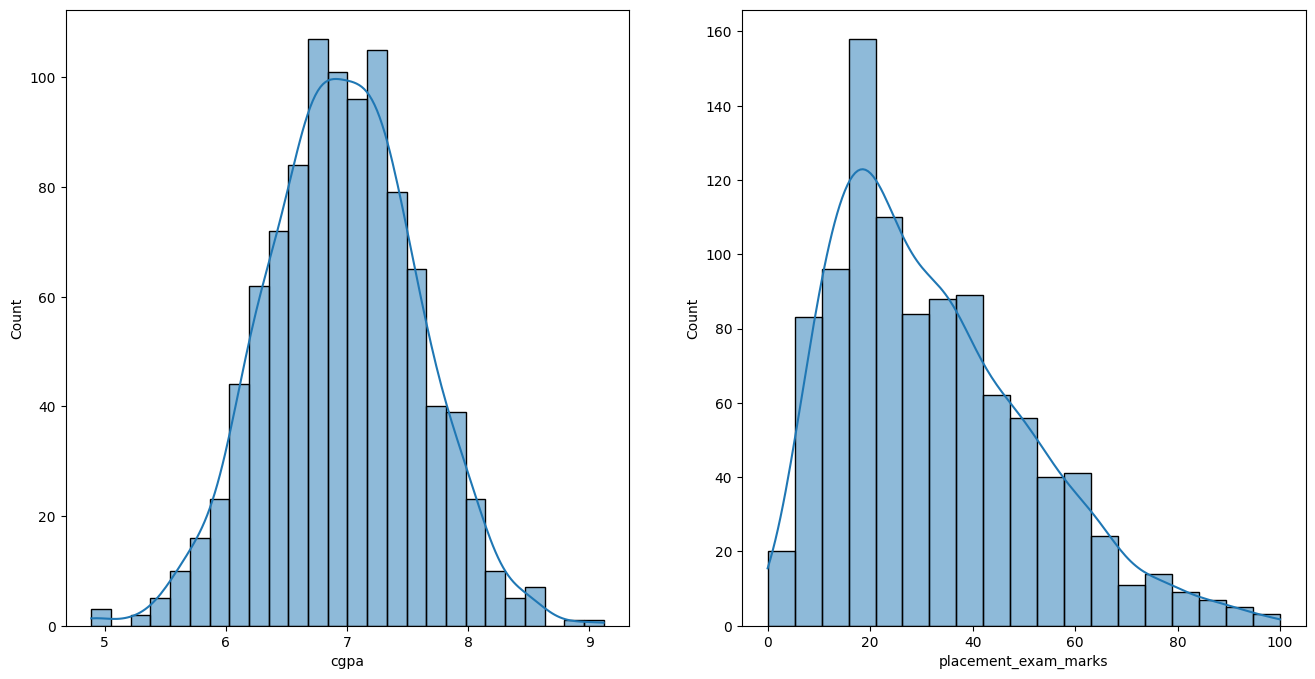

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True)
plt.show()

In [ ]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


<Axes: xlabel='placement_exam_marks'>

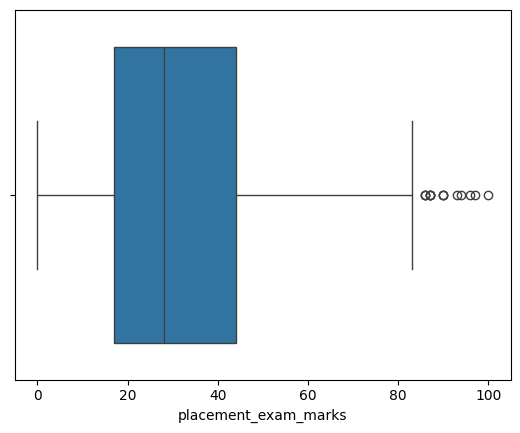

In [ ]:
sns.boxplot(x=df['placement_exam_marks'])

In [ ]:
# finding the IQR
percentile25=df['placement_exam_marks'].quantile(0.25)
percentile25f=float(percentile25)
percentile75=df['placement_exam_marks'].quantile(0.75)
percentile75f=float(percentile75)
print(percentile25f)
print(percentile75f)

17.0
44.0


In [ ]:
iqr=percentile75f-percentile25f
iqr

27.0

In [ ]:
upper_limit=percentile75f + 1.5 * iqr
lower_limit=percentile25f - 1.5 * iqr
print("Upper limit",upper_limit)
print("Lower Limit",lower_limit)

Upper limit 84.5
Lower Limit -23.5


**Finding Outliers**

In [ ]:
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [ ]:
df[df['placement_exam_marks']<lower_limit]

,cgpa,placement_exam_marks,placed


**Trimming**

In [ ]:
new_df=df[(df['placement_exam_marks']<upper_limit) & (df['placement_exam_marks']>lower_limit)]
new_df.shape

(985, 3)

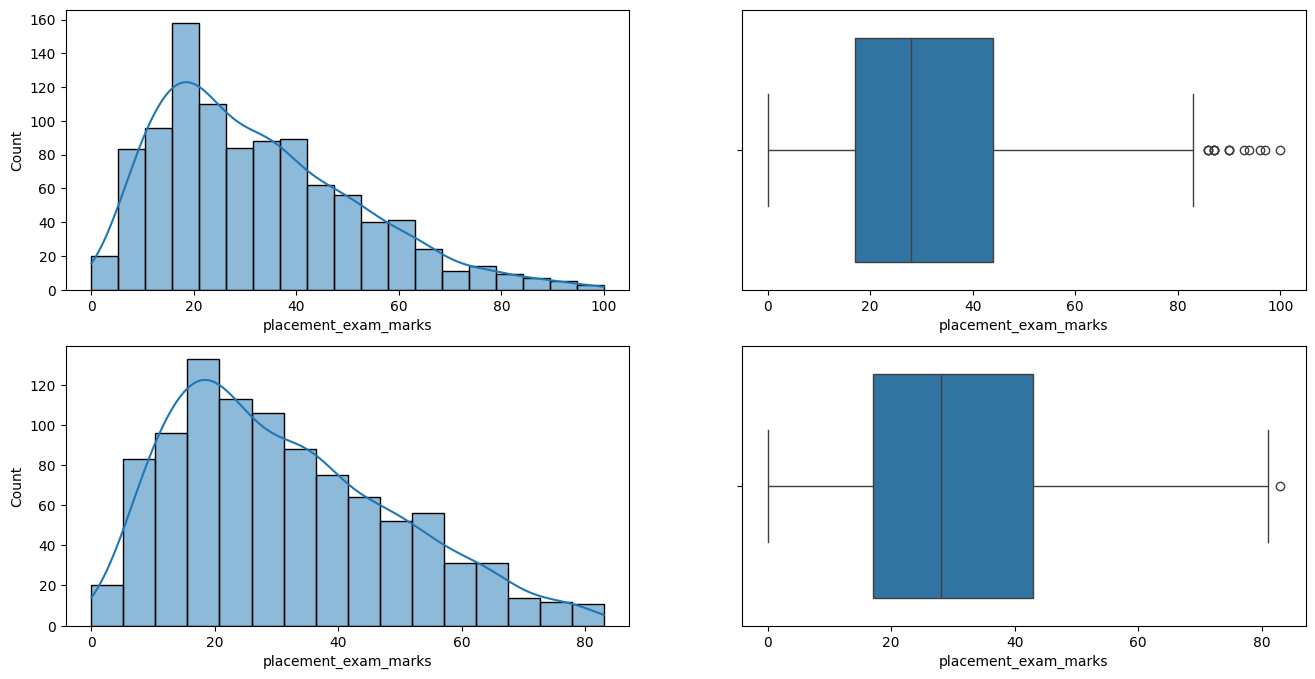

In [ ]:
# comparing
plt.figure(figsize=(16,8))

plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'],kde=True)

plt.subplot(2,2,4)
sns.boxplot(x=new_df['placement_exam_marks'])

plt.show()


**Capping**

In [ ]:
new_df_cap=df.copy()

new_df_cap['placement_exam_marks']=np.where(
    new_df_cap['placement_exam_marks']>upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks']<lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
  )

In [ ]:
new_df_cap.shape

(1000, 3)

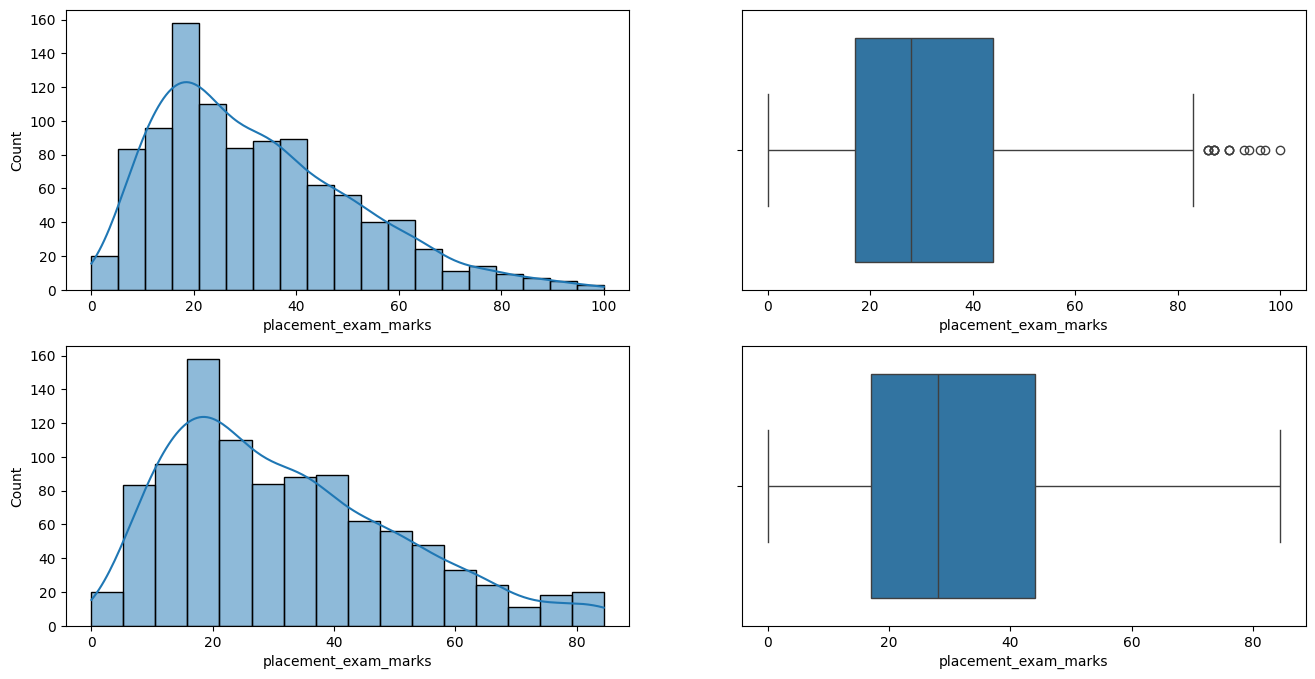

In [ ]:
# comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(x=df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'],kde=True)

plt.subplot(2,2,4)
sns.boxplot(x=new_df_cap['placement_exam_marks'])

plt.show()